In [3]:
# importing necessary libraries
from time import process_time
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random
import math
from scipy import sparse
from scipy.sparse import random
from scipy.stats import skewnorm
from scipy import stats
from numpy.random import default_rng
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd

In [2]:
# importing algorithm functions
import sys
sys.path.insert(1, '../functions')
from gk import gk
from mwrko import mwrko
from gko import gko
from method import method

# Synthetic Experiment: Skewed Distribution

We test the algorithms, and compare the iteration numbers using skewed distributions (right, left, and long-tailed normal distribution).

The pdf of skewed distribution is $skewnorm.pdf(x, a) = 2 * norm.pdf(x) * norm.cdf(a*x)$, where $a$ determines the skeweness of distribution

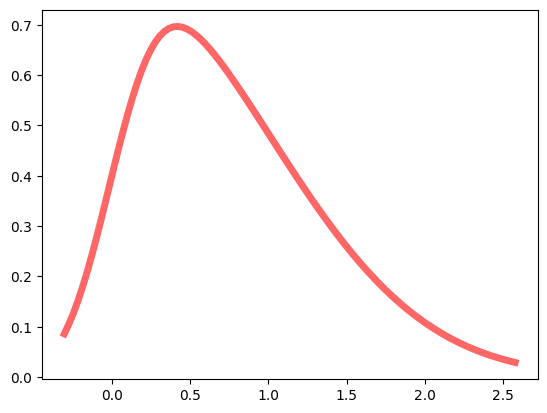

In [16]:
# calculate first four moments
mean, var, skew, kurt = skewnorm.stats(4, moments='mvsk')

# compute pdf
x = np.linspace(skewnorm.ppf(0.01, 4), skewnorm.ppf(0.99, 4), 100)
# plot pdf
fig, ax = plt.subplots(1, 1)
ax.plot(x, skewnorm.pdf(x, 4), 'r-', lw=5, alpha=0.6, label='skewnorm pdf')

In [31]:
# generate 1000 x 500 linear system from skewed distribution
A = np.linspace(skewnorm.ppf(0.01, 4), skewnorm.ppf(0.99, 4), 1000*500)
A = A.reshape((1000,500))
# finalize system
x = np.ones(500)
y = A @ x


In [38]:
# run algorithms

# gk
gk_rsk = gk(A,x,y, 0.5*10**(-8))
# gko
gko_rsk = gko(A,x,y, 0.5*10**(-8))
# mwrko
mwrko_rsk = mwrko(A,x,y, 0.5*10**(-8))

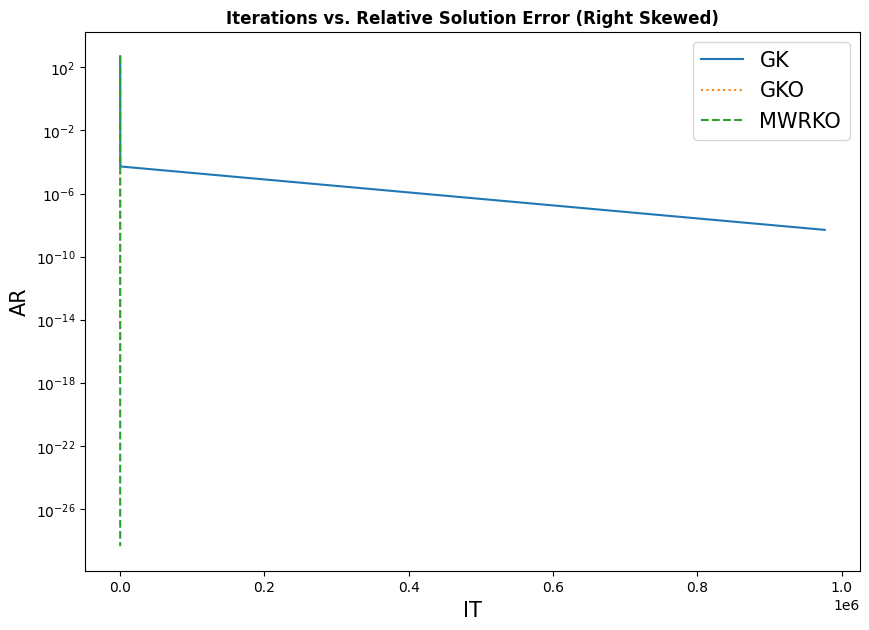

In [36]:
plt.figure(figsize=(10,7))

plt.semilogy(np.arange(gk_rsk[0]), gk_rsk[1], linestyle = 'solid', label = 'GK')
plt.semilogy(np.arange(gko_rsk[0]), gko_rsk[1], linestyle = 'dotted', label = 'GKO')
plt.semilogy(np.arange(mwrko_rsk[0]), mwrko_rsk[1], linestyle = 'dashed', label = 'MWRKO')

plt.xlabel('IT', fontsize = 15)
plt.ylabel('AR', fontsize = 15)
plt.title('Iterations vs. Relative Solution Error (Right Skewed)', fontweight="bold")
plt.legend(fontsize="15")

In [42]:
mwrko_rsk[0]

3